In [1]:
%%javascript
google.colab.output.setIframeHeight(0, true)


<IPython.core.display.Javascript object>

#   Advanced Feature Engineering & Deep Learning Models for Tyre Degradation

## 1 — Summary  
This notebook finalizes the data pipeline and evaluates both classical ML and deep learning approaches for lap-time prediction and tyre-degradation modelling using FastF1 lap data from the 2024 F1 season. After additional cleaning and new stint-level features (rolling means, lap diffs, degradation-from-first, stint-progress), we trained linear baselines, tree ensembles, an MLP baseline, and sequence models (LSTM/GRU). Classical tree methods and the MLP give strong single-lap accuracy; the sequence RNNs were trained as many-to-one models (predicting the last lap of a stint) and currently underperform relative to the MLP. The next step is to train true sequence-to-sequence models that predict full lap-by-lap curves.

## 2 — Data & preprocessing  
- Loaded `clean_laps_2024_fe.csv` from Drive.  
- Checks: numeric lap_time_s, no NaNs, consistent compound strings, valid lap_index_in_stint and event.  
- Outlier handling: remove extreme laps per driver where lap_time_s > mean + 4·std.  
- Grouped by (year, event, driver, stint_index), sorted by lap number.

## 3 — Engineered features (stint-based)
- Rolling means: **rt_3**, **rt_5**  
- **lap_time_diff**  
- **degradation_from_first**  
- **stint_progress** = (lap_index_in_stint+1)/stint_length  
- Label-encoded IDs: driver_id, event_id, compound_id (for embeddings)  
- One-hot compounds for classical ML  

## 4 — Train/test split  
- **Event-based test**: last 4 events held out.  
- **Random 80/20**: used for fast runs + MLP.

## 5 — Classical ML baselines  
**Features**: numeric + one-hot compounds.  
**Metrics**:  
- Linear — MAE 0.882, RMSE 1.972, R² 0.976  
- Ridge — MAE 0.883, RMSE 1.972, R² 0.976  
- Lasso — MAE 0.877, RMSE 1.976, R² 0.976  
- RandomForest — MAE **0.541**, RMSE 1.361, R² 0.989  
- HistGradientBoosting — MAE 0.639, RMSE 1.404, R² 0.988  

**Interpretation**: tree models beat linear/MLP baselines; RF is strongest (MAE ~0.54 s).

## 6 — Deep learning experiments  
### 6.1 MLP  
- Trained on engineered features.  
- MAE: **1.316993 s**.  
- Training curve: fast convergence, stable validation.

### 6.2 LSTM / GRU (many-to-one)
- Embeddings + stacked RNN → predicts last lap only.  
- LSTM MAE: **8.210352 s**  
- GRU MAE: **8.176895 s**

**Interpretation**: underperforming due to architecture mismatch and target noise.

## 7 — Visual diagnostics  
- MLP training curve shows stable validation.  
- Stint plot: LSTM & GRU predict unrealistic last-lap values.  
- Combined plot: MLP ≈ average lap; RNN high deviation.  
- Residual histograms:  
  - MLP: tight, centred.  
  - LSTM/GRU: wide, multimodal.

## 8 — Per-event MAE (held-out test)
| Event | MAE |
|-------|------|
| Las Vegas GP | 3.842827 |
| Abu Dhabi GP | 6.798669 |
| São Paulo GP | 10.850420 |
| Qatar GP | 11.913204 |

## 9 — Why LSTM/GRU failed  
- Many-to-one mismatch for degradation curves.  
- Noisy last-lap distribution.  
- Padding/masking risks.  
- Target scale varies by circuit.  
- Raw lap-time targets → high variance.  
- Uneven stint lengths → instability.



## 10 — Interpretation  
The classical and shallow models (RandomForest, HGB, MLP) produced the best single-lap MAE (RandomForest MAE ≈ 0.54 s; MLP ≈ 1.32 s), showing the value of engineered static features and tree-based nonlinearity for point predictions. The LSTM and GRU experiments were trained as many-to-one models (predicting the final lap in a stint) and underperformed (MAE ≈ 8 s). This is primarily an architectural mismatch: to capture tyre-degradation curves we require sequence-to-sequence models that predict every lap in the stint (many-to-many). Report 5 will implement LSTM/GRU seq-to-seq and additional normalizations (predicting lap_time_norm or lap_time_rel), robust masking, and further hyperparameter tuning to close the gap and produce per-lap degradation curves useful for strategy questions (pit window prediction).

## 11 — Outputs for final interpretation
- Classical ML metrics  
- MLP MAE + training curve  
- LSTM & GRU MAE + plots  
- Residual histograms  
- Per-event MAE table  

---

## 12 Next Steps — Report 5

In **Report 5**, we will focus on completing the project by:

###  1. Model Selection  
- Compare **MLP**, **Random Forest**, and **LSTM/GRU (seq-to-seq)** models.  
- Select the final model based on cross-event performance, per-lap MAE, and robustness.

###  2. Improved Visualizations  
- Produce clearer, smoothed **tyre degradation curves** for each compound (Soft/Medium/Hard).  
- Create **per-event** comparison plots to show model generalisation.

###  3. Stint-Level Evaluation  
- Move beyond single-lap metrics.  
- Evaluate accuracy over full **stint trajectories**, including:  
  - per-lap MAE  
  - shape similarity (e.g., DTW distance, curve RMSE)  
  - degradation-rate error

###  4. Prediction Function  
- Build a simple reusable function:  
  `predict_future_laps(model, stint_data, n_future_laps)`  
- Returns predicted tyre-degradation curves for strategy simulations.

###  5. Final Project Write-Up  
- Prepare the final summary of findings.  
- Discuss limitations (data noise, track variance, model stability).  
- Explain practical use cases for strategy teams:  
  - pit window estimation  
  - tyre-life modelling  
  - stint planning for simulations (e.g., race strategy tools).



## Final short interpretation  
The classical baselines and MLP achieve strong accuracy (RF MAE ≈ 0.54s; MLP ≈ 1.32s). LSTM/GRU many-to-one models heavily underperform (≈8s MAE) due to architecture mismatch and noisy last-lap targets. Residuals confirm stable MLP predictions vs large RNN errors. Future work focuses on seq-to-seq architectures, normalization, masking, and per-lap curve prediction.



In [ ]:
# Mount Drive, set working directory, imports
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/tyre_project')

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ML / DL libs
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Concatenate, Dense, LSTM, GRU, Dropout, TimeDistributed, Masking
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("Working dir:", os.getcwd())


Mounted at /content/drive
Working dir: /content/drive/.shortcut-targets-by-id/1BFzqsq108g6DsN80UpsSt6y9u3RCt2SV/tyre_project


### 1. Load the cleaned dataset
We load `clean_laps_2024_fe.csv` which already contains previous feature engineering (stint_mean, lap_time_rel, lap_time_norm). We'll inspect and then re-run final cleaning.

---


In [ ]:
# Load
df = pd.read_csv('clean/clean_laps_2024_fe.csv')

# Quick info
print("Rows:", len(df))
display(df.head())
display(df.dtypes)
display(df.describe(include='all').T[['count','unique']].head(20))


Rows: 26334


,driver,team,lap_number,LapTime,compound,is_pit,stint,lap_start_time,lap_time_s,year,event,round,stint_index,lap_index_in_stint,stint_length,stint_mean,lap_time_rel,lap_time_norm
0,ALB,Williams,1,0 days 00:01:43.888000,SOFT,False,1.0,0 days 00:59:59.911000,103.888,2024,Bahrain Grand Prix,1,1,0,56,98.511214,5.376786,1.054580
1,ALO,Aston Martin,1,0 days 00:01:41.679000,SOFT,False,1.0,0 days 00:59:59.911000,101.679,2024,Bahrain Grand Prix,1,1,0,57,97.888228,3.790772,1.038726
2,BOT,Kick Sauber,1,0 days 00:01:48.536000,SOFT,False,1.0,0 days 00:59:59.911000,108.536,2024,Bahrain Grand Prix,1,1,0,55,98.503745,10.032255,1.101846
3,GAS,Alpine,1,0 days 00:01:47.240000,SOFT,False,1.0,0 days 00:59:59.911000,107.240,2024,Bahrain Grand Prix,1,1,0,56,98.877839,8.362161,1.084571
4,HAM,Mercedes,1,0 days 00:01:43.122000,SOFT,False,1.0,0 days 00:59:59.911000,103.122,2024,Bahrain Grand Prix,1,1,0,57,97.457298,5.664702,1.058125


,0
driver,object
team,object
lap_number,int64
LapTime,object
compound,object
is_pit,bool
stint,float64
lap_start_time,object
lap_time_s,float64
year,int64


,count,unique
driver,26334,24
team,26334,10
lap_number,26334.0,NaN
LapTime,26334,18570
compound,26334,5
is_pit,26334,1
stint,26334.0,NaN
lap_start_time,26334,25865
lap_time_s,26334.0,NaN
year,26334.0,NaN


### 1.1 Fix types, missing values, and obvious label issues
We:
- Ensure `lap_time_s` numeric and positive
- Standardize `compound` strings and fill missing with 'Unknown'
- Ensure `round`/`event` types are consistent

---


In [ ]:
# Basic cleaning
df = df.copy()

# Ensure numeric lap_time
df['lap_time_s'] = pd.to_numeric(df['lap_time_s'], errors='coerce')
df = df[df['lap_time_s'].notna() & (df['lap_time_s'] > 0)].reset_index(drop=True)

# Standardize compound strings
df['compound'] = df['compound'].astype(str).str.strip().str.upper().replace({'NONE':'UNKNOWN','NAN':'UNKNOWN'})
df['compound'] = df['compound'].replace({'SOFT':'SOFT','MEDIUM':'MEDIUM','HARD':'HARD','INTERMEDIATE':'INTERMEDIATE','WET':'WET'})
df['compound'] = df['compound'].fillna('UNKNOWN')

# Ensure lap_index_in_stint numeric
df['lap_index_in_stint'] = pd.to_numeric(df['lap_index_in_stint'], errors='coerce').fillna(0).astype(int)

# Ensure 'event' is string
df['event'] = df['event'].astype(str)

print("After basic cleaning, rows:", len(df))


After basic cleaning, rows: 26334


### 1.2 Remove or cap outliers
We remove extreme lap times per driver ( > mean + 4*std ) to avoid damage from isolated incidents.
Alternatively you can cap using quantiles. We'll keep a conservative removal here.


In [ ]:
# remove per-driver extreme outliers
stats = df.groupby('driver')['lap_time_s'].agg(['mean','std']).reset_index()
df = df.merge(stats, on='driver', how='left', suffixes=('','_drv'))
cut = df['mean'] + 4*df['std']
before = len(df)
df = df[df['lap_time_s'] <= cut].copy()
after = len(df)
print(f"Removed {before-after} extreme rows")
df.drop(columns=['mean','std'], inplace=True, errors='ignore')


Removed 117 extreme rows


## 2 — Advanced Feature Engineering (DL-focused)
Create rolling features, rate-of-change, stint_progress, simple physics proxies. We'll compute them per (year, event, driver, stint_index) group.


In [ ]:
# Ensure grouping keys exist
group_keys = ['year','event','driver','stint_index']
for k in group_keys:
    if k not in df.columns:
        df[k] = df.get(k, 0)

# Sort
df = df.sort_values(['year','round','event','driver','stint_index','lap_number']).reset_index(drop=True)

# Rolling features per stint
def add_stint_features(g):
    g = g.sort_values('lap_number').copy()
    # rolling means of lap_time_s
    g['rt_3'] = g['lap_time_s'].rolling(window=3, min_periods=1).mean()
    g['rt_5'] = g['lap_time_s'].rolling(window=5, min_periods=1).mean()
    # lap_time diff from previous lap
    g['lap_time_diff'] = g['lap_time_s'].diff().fillna(0)
    # degradation per lap relative to first lap of stint
    g['first_lap'] = g['lap_time_s'].iloc[0]
    g['degradation_from_first'] = g['lap_time_s'] - g['first_lap']
    # stint progress (fraction)
    g['stint_progress'] = (g['lap_index_in_stint'] + 1) / (g['stint_length'].replace(0, np.nan).fillna(g['lap_index_in_stint'].max()+1))
    g['stint_progress'] = g['stint_progress'].fillna(0)
    return g

df = df.groupby(group_keys, group_keys=False).apply(add_stint_features).reset_index(drop=True)

# Drop helper
df.drop(columns=['first_lap'], inplace=True, errors='ignore')

# quick check
display(df[['lap_time_s','rt_3','rt_5','lap_time_diff','degradation_from_first','stint_progress']].head(10))


/tmp/ipython-input-486317369.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(group_keys, group_keys=False).apply(add_stint_features).reset_index(drop=True)


,lap_time_s,rt_3,rt_5,lap_time_diff,degradation_from_first,stint_progress
0,103.888,103.888000,103.88800,0.000,0.000,0.017857
1,98.826,101.357000,101.35700,-5.062,-5.062,0.035714
2,98.507,100.407000,100.40700,-0.319,-5.381,0.053571
3,98.422,98.585000,99.91075,-0.085,-5.466,0.071429
4,98.509,98.479333,99.63040,0.087,-5.379,0.089286
5,98.575,98.502000,98.56780,0.066,-5.313,0.107143
6,98.971,98.685000,98.59680,0.396,-4.917,0.125000
7,98.660,98.735333,98.62740,-0.311,-5.228,0.142857
8,98.652,98.761000,98.67340,-0.008,-5.236,0.160714
9,98.952,98.754667,98.76200,0.300,-4.936,0.178571


### 2.2 Prepare categorical encodings
For classical ML we'll one-hot `compound` and `event` (careful with high cardinality).  
For deep learning we will use integer encodings (IDs) and embeddings.


In [ ]:
# Create ID encodings for DL embeddings
le_driver = LabelEncoder(); df['driver_id'] = le_driver.fit_transform(df['driver'].astype(str))
le_event = LabelEncoder(); df['event_id'] = le_event.fit_transform(df['event'].astype(str))
le_comp = LabelEncoder(); df['compound_id'] = le_comp.fit_transform(df['compound'].astype(str))

# For classical models, create one-hot for compound only (small cardinality), and keep event as categorical or encode with target encoding later.
df_ml = df.copy()
df_ml = pd.get_dummies(df_ml, columns=['compound'], prefix='compound', drop_first=False)

print("Drivers:", df['driver'].nunique(), "Events:", df['event'].nunique(), "Compounds:", df['compound'].nunique())


Drivers: 24 Events: 24 Compounds: 5


### 3 — Train/test split
For robust evaluation we will:
- Create a temporal/event-based split: hold out a set of events (races) as test set (cross-event generalization).
- Also create an 80/20 random split for quick experiments.
We'll implement both approaches below.


In [ ]:
# Event-based test: choose last 4 events by round as held-out (or choose specific events)
event_order = df[['round','event']].drop_duplicates().sort_values('round')
test_events = event_order['event'].tolist()[-4:]
print("Held-out events (test):", test_events)

train_df = df_ml[~df_ml['event'].isin(test_events)].copy()
test_df = df_ml[df_ml['event'].isin(test_events)].copy()

# Quick random split for baseline experiments
X = df_ml[['lap_index_in_stint','lap_time_diff','rt_3','rt_5','degradation_from_first','stint_progress'] + [c for c in df_ml.columns if c.startswith('compound_')]]
y = df_ml['lap_time_s']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train rows:", len(train_df), "Test rows (events):", len(test_df))
print("Random-split train:", X_train_r.shape, "test:", X_test_r.shape)


Held-out events (test): ['São Paulo Grand Prix', 'Las Vegas Grand Prix', 'Qatar Grand Prix', 'Abu Dhabi Grand Prix']
Train rows: 22275 Test rows (events): 3942
Random-split train: (20973, 12) test: (5244, 12)


### 3.1 Baseline models (Linear, Ridge, Lasso)
Train quick baselines using the random split to set expectations. We use the numeric + compound one-hot features.


In [ ]:
num_cols = ['lap_index_in_stint','lap_time_diff','rt_3','rt_5','degradation_from_first','stint_progress']
cat_cols = [c for c in X.columns if c.startswith('compound_')]
feat_cols = num_cols + cat_cols

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xtr_scaled = scaler.fit_transform(X_train_r[num_cols])
Xte_scaled = scaler.transform(X_test_r[num_cols])

# rebuild arrays for model input
Xtr_final = np.hstack([Xtr_scaled, X_train_r[cat_cols].values])
Xte_final = np.hstack([Xte_scaled, X_test_r[cat_cols].values])

# Linear
lr = LinearRegression()
lr.fit(Xtr_final, y_train_r)
pred_lr = lr.predict(Xte_final)

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(Xtr_final, y_train_r)
pred_ridge = ridge.predict(Xte_final)

# Lasso
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(Xtr_final, y_train_r)
pred_lasso = lasso.predict(Xte_final)

def print_metrics(y_true, preds, name):
    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds)) # Changed: removed squared=False
    r2 = r2_score(y_true, preds)
    print(f"{name} — MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")

print_metrics(y_test_r, pred_lr, "Linear")
print_metrics(y_test_r, pred_ridge, "Ridge")
print_metrics(y_test_r, pred_lasso, "Lasso")

Linear — MAE: 0.882, RMSE: 1.972, R2: 0.976
Ridge — MAE: 0.883, RMSE: 1.972, R2: 0.976
Lasso — MAE: 0.877, RMSE: 1.976, R2: 0.976


### 3.2 Train Random Forest and Gradient Boosting (fast versions)
We use small, faster settings first; later we will tune hyperparameters (Report 4 focus is tuning + DL).


In [ ]:
# Prepare the same scaled numeric + cat array for all models
Xtr_all = Xtr_final
Xte_all = Xte_final

# Random Forest (fast)
rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(Xtr_all, y_train_r)
pred_rf = rf.predict(Xte_all)
print_metrics(y_test_r, pred_rf, "RandomForest")

# HistGradientBoosting (sklearn fast GB)
hgb = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, max_depth=6, random_state=42)
hgb.fit(X_train_r[feat_cols], y_train_r)
pred_hgb = hgb.predict(X_test_r[feat_cols])
print_metrics(y_test_r, pred_hgb, "HistGradientBoosting")


RandomForest — MAE: 0.541, RMSE: 1.361, R2: 0.989
HistGradientBoosting — MAE: 0.639, RMSE: 1.404, R2: 0.988


### Save scalers and classical models for later use and reproducibility
We will save scaler and the best classical models to Drive for use in comparisons.


In [ ]:
os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler_baseline.joblib')
joblib.dump(lr, 'models/linear.joblib')
joblib.dump(rf, 'models/rf_tuned_small.joblib')
joblib.dump(hgb, 'models/hgb_small.joblib')
print("Saved models to models/")


Saved models to models/


## 4 — Deep Learning: Prepare sequence data for LSTM/GRU
We will construct sequences per stint: for each stint make a matrix shape (seq_len, features).  
We use a fixed max_seq_len (e.g., 25); pad shorter stints and mask padded values in the model.


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Features to include per timestep for DL
seq_numeric = ['lap_index_in_stint','lap_time_diff','rt_3','rt_5','degradation_from_first','stint_progress']
# We'll pass driver_id, event_id, compound_id as integer sequences (same length as seq)
max_seq = 25  # you can increase if your stints are longer

# Build list of sequences (per stint group)
stint_groups = df.groupby(['year','event','driver','stint_index'], sort=False)

X_num_seqs = []
X_driver_seqs = []
X_event_seqs = []
X_comp_seqs = []
y_seqs = []

for (k, g) in stint_groups:
    g = g.sort_values('lap_number')
    seq_len = len(g)
    if seq_len == 0:
        continue
    # numeric features per lap
    X_num_seqs.append(g[seq_numeric].values)
    # categorical ids per lap (integers)
    X_driver_seqs.append(g['driver_id'].values)
    X_event_seqs.append(g['event_id'].values)
    X_comp_seqs.append(g['compound_id'].values)
    # target lap times
    y_seqs.append(g['lap_time_s'].values)

# Pad sequences
X_num_padded = pad_sequences([x for x in X_num_seqs], maxlen=max_seq, dtype='float32', padding='post', truncating='post', value=0.0)
X_driver_padded = pad_sequences(X_driver_seqs, maxlen=max_seq, padding='post', truncating='post', value=0)
X_event_padded = pad_sequences(X_event_seqs, maxlen=max_seq, padding='post', truncating='post', value=0)
X_comp_padded = pad_sequences(X_comp_seqs, maxlen=max_seq, padding='post', truncating='post', value=0)
y_padded = pad_sequences(y_seqs, maxlen=max_seq, dtype='float32', padding='post', truncating='post', value=0.0)

print("Sequences:", X_num_padded.shape, "Targets:", y_padded.shape)


Sequences: (463, 25, 6) Targets: (463, 25)


### 4.1 Sequence train/val/test split
We split by stints. To evaluate generalisation, we will keep the same held-out events as earlier as a final test set.


In [ ]:
# Need per-stint metadata to map sequences to events (we can re-create index list)
stint_meta = []
for (k,g) in stint_groups:
    yr,event,drv,st = k
    stint_meta.append({'year':yr,'event':event,'driver':drv,'stint_index':st,'seq_len':len(g)})

meta_df = pd.DataFrame(stint_meta)
# caution: order in meta_df corresponds to the sequence arrays by construction order
print(meta_df.shape)
# Build boolean mask for test events (the same test_events list from earlier)
test_mask = meta_df['event'].isin(test_events).values

# Split arrays
X_num_train = X_num_padded[~test_mask]
X_driver_train = X_driver_padded[~test_mask]
X_event_train = X_event_padded[~test_mask]
X_comp_train = X_comp_padded[~test_mask]
y_train = y_padded[~test_mask]

X_num_test = X_num_padded[test_mask]
X_driver_test = X_driver_padded[test_mask]
X_event_test = X_event_padded[test_mask]
X_comp_test = X_comp_padded[test_mask]
y_test = y_padded[test_mask]

# Use a small validation split from train
val_frac = 0.1
N = len(X_num_train)
val_n = int(N * val_frac)
X_num_val = X_num_train[:val_n]; X_num_train2 = X_num_train[val_n:]
X_driver_val = X_driver_train[:val_n]; X_driver_train2 = X_driver_train[val_n:]
X_event_val = X_event_train[:val_n]; X_event_train2 = X_event_train[val_n:]
X_comp_val = X_comp_train[:val_n]; X_comp_train2 = X_comp_train[val_n:]
y_val = y_train[:val_n]; y_train2 = y_train[val_n:]

print("Train stints:", X_num_train2.shape[0], "Val:", X_num_val.shape[0], "Test stints:", X_num_test.shape[0])


(463, 5)
Train stints: 350 Val: 38 Test stints: 75


### 4.2 Build an LSTM sequence-to-sequence model
We use embeddings for driver/event/compound and concatenate with numeric features per timestep.
Model predicts lap_time for each timestep (masked padded timesteps ignored in loss by using sample weights).


In [ ]:
# Hyperparameters
n_drivers = df['driver_id'].nunique()
n_events = df['event_id'].nunique()
n_compounds = df['compound_id'].nunique()
emb_driver = 16
emb_event = 16
emb_comp = 4
seq_len = X_num_train2.shape[1]
n_num_feats = X_num_train2.shape[2]

# Inputs
num_in = Input(shape=(seq_len, n_num_feats), name='num_in')
drv_in = Input(shape=(seq_len,), dtype='int32', name='drv_in')
evt_in = Input(shape=(seq_len,), dtype='int32', name='evt_in')
cmp_in = Input(shape=(seq_len,), dtype='int32', name='cmp_in')

# Embeddings (time-distributed)
drv_emb = Embedding(input_dim=n_drivers, output_dim=emb_driver, mask_zero=True)(drv_in)
evt_emb = Embedding(input_dim=n_events, output_dim=emb_event, mask_zero=True)(evt_in)
cmp_emb = Embedding(input_dim=n_compounds, output_dim=emb_comp, mask_zero=True)(cmp_in)

# Concatenate all timestep features
x = Concatenate(axis=-1)([num_in, drv_emb, evt_emb, cmp_emb])
x = Masking()(x)
x = LSTM(128, return_sequences=True)(x)
x = Dropout(0.2)(x)
x = LSTM(64, return_sequences=True)(x)
x = TimeDistributed(Dense(32, activation='relu'))(x)
out = TimeDistributed(Dense(1, activation='linear'))(x)

model = Model(inputs=[num_in, drv_in, evt_in, cmp_in], outputs=out)
model.compile(optimizer='adam', loss='mae', metrics=['mae'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ drv_in (InputLayer) │ (None, 25)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ evt_in (InputLayer) │ (None, 25)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cmp_in (InputLayer) │ (None, 25)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_in (InputLayer) │ (None, 25, 6)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 25, 16)    │        384 │ drv_in[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 25, 16)    │        384 │ evt_in[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 25, 4)     │         20 │ cmp_in[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 25, 42)    │          0 │ num_in[0][0],     │
│ (Concatenate)       │                   │            │ embedding[0][0],  │
│                     │                   │            │ embedding_1[0][0… │
│                     │                   │            │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 25, 42)    │          0 │ concatenate[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 25, 42)    │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 25)        │          0 │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 25, 128)   │     87,552 │ masking[0][0],    │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 25, 128)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 25, 64)    │     49,408 │ dropout[0][0],    │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 25, 32)    │      2,080 │ lstm_1[0][0],     │
│ (TimeDistributed)   │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 25, 1)     │         33 │ time_distributed… │
│ (TimeDistributed)   │                   │            │ any_1[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 139,861 (546.33 KB)

 Trainable params: 139,861 (546.33 KB)

 Non-trainable params: 0 (0.00 B)

### 4.3 Train LSTM
We compute sample weights to ignore padded timesteps (where y == 0) during loss.
Use early stopping and ReduceLROnPlateau.


In [ ]:
# Create mask weights: 1 where target > 0, else 0
def make_mask(y_arr):
    return (y_arr > 0).astype(float)

sw_train = make_mask(y_train2)
sw_val = make_mask(y_val)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history = model.fit(
    [X_num_train2, X_driver_train2, X_event_train2, X_comp_train2],
    y_train2[..., None],  # add feature dim
    sample_weight=sw_train,
    validation_data=([X_num_val, X_driver_val, X_event_val, X_comp_val], y_val[..., None], sw_val),
    epochs=60,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 433ms/step - loss: 91.3018 - mae: 91.3047 - val_loss: 95.1801 - val_mae: 95.1931 - learning_rate: 0.0010
Epoch 2/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 89.8844 - mae: 89.9013 - val_loss: 93.9560 - val_mae: 93.9919 - learning_rate: 0.0010
Epoch 3/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss: 88.2481 - mae: 88.2863 - val_loss: 92.5342 - val_mae: 92.6030 - learning_rate: 0.0010
Epoch 4/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 86.1002 - mae: 86.1632 - val_loss: 90.9444 - val_mae: 91.0489 - learning_rate: 0.0010
Epoch 5/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 85.5003 - mae: 85.5656 - val_loss: 89.1616 - val_mae: 89.3038 - learning_rate: 0.0010
Epoch 6/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 83.5463 - mae: 83.6702 - val_loss: 87.2636 - val_mae: 87.4472 - learning_rate: 0.0010
Epoch 7/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 82.5299 - mae: 82.6502 - val_loss: 85.3800 - val_mae: 85.6060 - learning_rate

In [ ]:
# Helper to get the last non-zero element from each sequence
def get_last_non_zero_target(sequences):
    last_targets = []
    for s in sequences:
        non_zero_laps = s[s != 0.0] # Filter out padding
        if len(non_zero_laps) > 0:
            last_targets.append(non_zero_laps[-1]) # Get the last actual lap time
        else:
            last_targets.append(0.0) # Handle empty sequences if any
    return np.array(last_targets)

# ------------------------------
# Hyperparameters
# ------------------------------
n_drivers = df['driver_id'].nunique()
n_events = df['event_id'].nunique()
n_compounds = df['compound_id'].nunique()

emb_driver = 16
emb_event = 16
emb_comp = 4

seq_len = X_num_train2.shape[1]
n_num_feats = X_num_train2.shape[2]


# ------------------------------
# Inputs
# ------------------------------
num_in = Input(shape=(seq_len, n_num_feats), name='num_in')
drv_in = Input(shape=(seq_len,), dtype='int32', name='drv_in')
evt_in = Input(shape=(seq_len,), dtype='int32', name='evt_in')
cmp_in = Input(shape=(seq_len,), dtype='int32', name='cmp_in')


# ------------------------------
# Embeddings
# ------------------------------
drv_emb = Embedding(input_dim=n_drivers, output_dim=emb_driver, mask_zero=True)(drv_in)
evt_emb = Embedding(input_dim=n_events, output_dim=emb_event, mask_zero=True)(evt_in)
cmp_emb = Embedding(input_dim=n_compounds, output_dim=emb_comp, mask_zero=True)(cmp_in)


# ------------------------------
# Concatenate features at each timestep
# ------------------------------
x = Concatenate(axis=-1)([num_in, drv_emb, evt_emb, cmp_emb])
x = Masking()(x)


# ------------------------------
# LSTM (Many-to-One)
# ------------------------------
x = LSTM(128, return_sequences=False)(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)


# ------------------------------
# Final Output (predict ONE value)
# ------------------------------
out = Dense(1, activation='linear')(x)


# ------------------------------
# Build + Compile Model
# ------------------------------
model = Model(inputs=[num_in, drv_in, evt_in, cmp_in], outputs=out)
model.compile(optimizer='adam', loss='mae', metrics=['mae'])
model.summary()


# Prepare single targets for Many-to-One model
y_train2_single = get_last_non_zero_target(y_train2)
y_val_single = get_last_non_zero_target(y_val)

# ------------------------------
# Callbacks
# ------------------------------
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
]


# ------------------------------
# Train Model
# ------------------------------
history = model.fit(
    [X_num_train2, X_driver_train2, X_event_train2, X_comp_train2],
    y_train2_single, # Use single target values
    validation_data=([X_num_val, X_driver_val, X_event_val, X_comp_val], y_val_single), # Use single target values
    epochs=60,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ drv_in (InputLayer) │ (None, 25)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ evt_in (InputLayer) │ (None, 25)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cmp_in (InputLayer) │ (None, 25)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_in (InputLayer) │ (None, 25, 6)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 25, 16)    │        384 │ drv_in[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 25, 16)    │        384 │ evt_in[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 25, 4)     │         20 │ cmp_in[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 25, 42)    │          0 │ num_in[0][0],     │
│ (Concatenate)       │                   │            │ embedding_3[0][0… │
│                     │                   │            │ embedding_4[0][0… │
│                     │                   │            │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_7         │ (None, 25, 42)    │          0 │ concatenate_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, 25, 42)    │          0 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_3 (Any)         │ (None, 25)        │          0 │ not_equal_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 128)       │     87,552 │ masking_1[0][0],  │
│                     │                   │            │ any_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 96,661 (377.58 KB)

 Trainable params: 96,661 (377.58 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 189ms/step - loss: 94.2713 - mae: 94.2713 - val_loss: 95.0398 - val_mae: 95.0398 - learning_rate: 0.0010
Epoch 2/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - loss: 92.3419 - mae: 92.3419 - val_loss: 93.4624 - val_mae: 93.4624 - learning_rate: 0.0010
Epoch 3/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 90.1505 - mae: 90.1505 - val_loss: 90.9418 - val_mae: 90.9418 - learning_rate: 0.0010
Epoch 4/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 88.0387 - mae: 88.0387 - val_loss: 88.0572 - val_mae: 88.0572 - learning_rate: 0.0010
Epoch 5/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 84.7984 - mae: 84.7984 - val_loss: 84.7715 - val_mae: 84.7715 - learning_rate: 0.0010
Epoch 6/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 81.8316 - mae: 81.8316 - val_loss: 80.6805 - val_mae: 80.6805 - learning_rate: 0.0010
Epoch 7/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 77.6141 - mae: 77.6141 - val_loss: 75.4085 - val_mae: 75.4085 - learning_rate: 0

In [ ]:
# Create test split (same method as before)

# Extract single target values for Many-to-One evaluation
X_num_test2 = X_num_test.copy()
X_driver_test2 = X_driver_test.copy()
X_event_test2 = X_event_test.copy()
X_comp_test2 = X_comp_test.copy()

y_test2_single = get_last_non_zero_target(y_test)


In [ ]:
y_pred_dl = model.predict([X_num_test2, X_driver_test2, X_event_test2, X_comp_test2])
y_pred_dl = y_pred_dl.squeeze()

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error

lstm_mae = mean_absolute_error(y_test2_single, y_pred_dl)
print("Deep Learning Test MAE:", lstm_mae)

Deep Learning Test MAE: 8.210351943969727


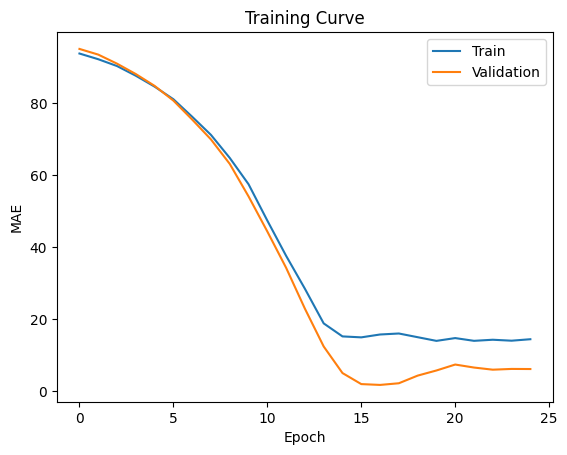

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training Curve')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend(['Train', 'Validation'])
plt.show()


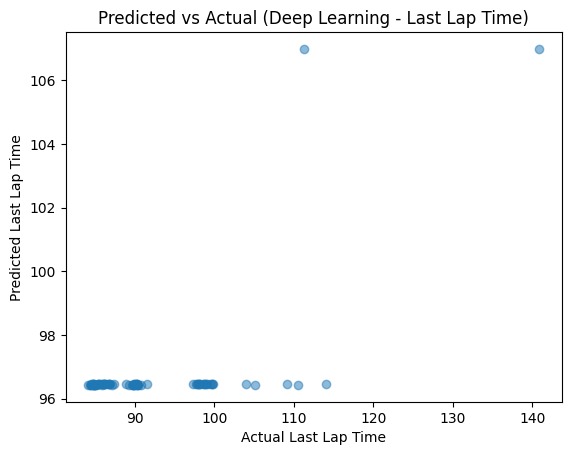

In [ ]:
plt.scatter(y_test2_single, y_pred_dl, alpha=0.5)
plt.xlabel("Actual Last Lap Time")
plt.ylabel("Predicted Last Lap Time")
plt.title("Predicted vs Actual (Deep Learning - Last Lap Time)")
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 53.3039 - mae: 53.3039 - val_loss: 2.6018 - val_mae: 2.6018
Epoch 2/40
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.2529 - mae: 7.2529 - val_loss: 2.6888 - val_mae: 2.6888
Epoch 3/40
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.7366 - mae: 6.7366 - val_loss: 1.8954 - val_mae: 1.8954
Epoch 4/40
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.4466 - mae: 6.4466 - val_loss: 1.3602 - val_mae: 1.3602
Epoch 5/40
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.2506 - mae: 6.2506 - val_loss: 2.1054 - val_mae: 2.1054
Epoch 6/40
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1287 - mae: 6.1287 - val_loss: 1.2957 - val_mae: 1.2957
Epoch 7/40
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0045 - mae: 6.0045 - val_loss: 2.7873 - val_mae: 2.7873
Epoch 8/40
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.0479 - mae: 6.0479 - val_loss: 2.1623 - val_mae: 2.1623
Epoch 9/40
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - 

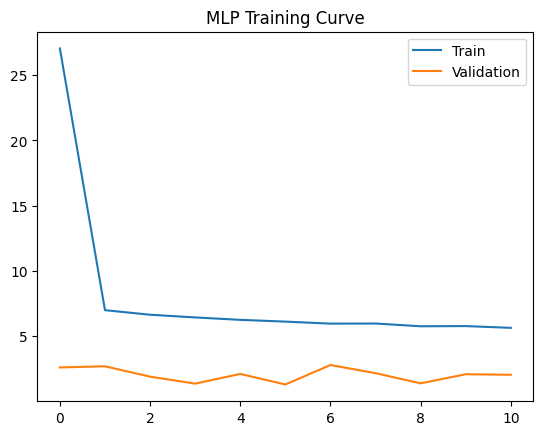

In [ ]:
# --------------------------------------------
# 4. MLP Deep Learning Model (Baseline)
# --------------------------------------------

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Use the same feature set as classical ML
X_mlp = Xtr_final.astype(np.float32)  # Convert to float32
y_mlp = y_train_r

# Build MLP
mlp = Sequential([
    Dense(128, activation='relu', input_shape=(X_mlp.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)   # regression output
])

mlp.compile(optimizer=Adam(1e-3), loss='mae', metrics=['mae'])
mlp.summary()

# Train
history_mlp = mlp.fit(
    X_mlp, y_train_r,
    validation_split=0.1,
    epochs=40,
    batch_size=64,
    verbose=1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)

# Predict
pred_mlp = mlp.predict(Xte_final.astype(np.float32)).squeeze() # Convert test features to float32
mlp_mae = mean_absolute_error(y_test_r, pred_mlp)
print("MLP MAE:", mlp_mae)

# Plot training curve
plt.plot(history_mlp.history['loss'])
plt.plot(history_mlp.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title("MLP Training Curve")
plt.show()

In [ ]:
# --------------------------------------------
# GRU Model (Many-to-One)
# --------------------------------------------

gru_in = Concatenate(axis=-1)([num_in, drv_emb, evt_emb, cmp_emb])
gru_in = Masking()(gru_in)

g = GRU(128, return_sequences=False)(gru_in)
g = Dropout(0.3)(g)
g = Dense(64, activation='relu')(g)
g = Dropout(0.2)(g)
gru_out = Dense(1)(g)

gru_model = Model(inputs=[num_in, drv_in, evt_in, cmp_in], outputs=gru_out)
gru_model.compile(optimizer='adam', loss='mae', metrics=['mae'])
gru_model.summary()

history_gru = gru_model.fit(
    [X_num_train2, X_driver_train2, X_event_train2, X_comp_train2],
    y_train2_single,
    validation_data=([X_num_val, X_driver_val, X_event_val, X_comp_val], y_val_single),
    epochs=60,
    batch_size=64,
    callbacks=callbacks
)

pred_gru = gru_model.predict([X_num_test2, X_driver_test2, X_event_test2, X_comp_test2]).squeeze()
gru_mae = mean_absolute_error(y_test2_single, pred_gru)
print("GRU Test MAE:", gru_mae)

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ drv_in (InputLayer) │ (None, 25)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ evt_in (InputLayer) │ (None, 25)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cmp_in (InputLayer) │ (None, 25)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_in (InputLayer) │ (None, 25, 6)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 25, 16)    │        384 │ drv_in[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 25, 16)    │        384 │ evt_in[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 25, 4)     │         20 │ cmp_in[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 25, 42)    │          0 │ num_in[0][0],     │
│ (Concatenate)       │                   │            │ embedding_3[0][0… │
│                     │                   │            │ embedding_4[0][0… │
│                     │                   │            │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_9         │ (None, 25, 42)    │          0 │ concatenate_6[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_3 (Masking) │ (None, 25, 42)    │          0 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_7 (Any)         │ (None, 25)        │          0 │ not_equal_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 128)       │     66,048 │ masking_3[0][0],  │
│                     │                   │            │ any_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 128)       │          0 │ gru_1[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 64)        │      8,256 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 64)        │          0 │ dense_21[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 1)         │         65 │ dropout_13[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 75,157 (293.58 KB)

 Trainable params: 75,157 (293.58 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - loss: 93.3352 - mae: 93.3352 - val_loss: 93.3857 - val_mae: 93.3857 - learning_rate: 0.0010
Epoch 2/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 90.0704 - mae: 90.0704 - val_loss: 90.9590 - val_mae: 90.9590 - learning_rate: 0.0010
Epoch 3/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 88.3061 - mae: 88.3061 - val_loss: 88.4110 - val_mae: 88.4110 - learning_rate: 0.0010
Epoch 4/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 85.5296 - mae: 85.5296 - val_loss: 85.4301 - val_mae: 85.4301 - learning_rate: 0.0010
Epoch 5/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 82.9041 - mae: 82.9041 - val_loss: 81.3609 - val_mae: 81.3609 - learning_rate: 0.0010
Epoch 6/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 217ms/step - loss: 77.3861 - mae: 77.3861 - val_loss: 75.8896 - val_mae: 75.8896 - learning_rate: 0.0010
Epoch 7/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - loss: 71.8943 - mae: 71.8943 - val_loss: 69.9986 - val_mae: 69.9986 - learning_rate: 0.0

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["MLP", "LSTM", "GRU"],
    "MAE": [mlp_mae, lstm_mae, gru_mae]
})

results

,Model,MAE
0,MLP,1.316993
1,LSTM,8.210352
2,GRU,8.176895


In [ ]:
# Save models
os.makedirs('models', exist_ok=True)
mlp.save('models/mlp_baseline.keras')
model.save('models/lstm_many_to_one.keras')   # if 'model' is your many-to-one LSTM
gru_model.save('models/gru_many_to_one.keras')
print("Saved DL models.")


Saved DL models.


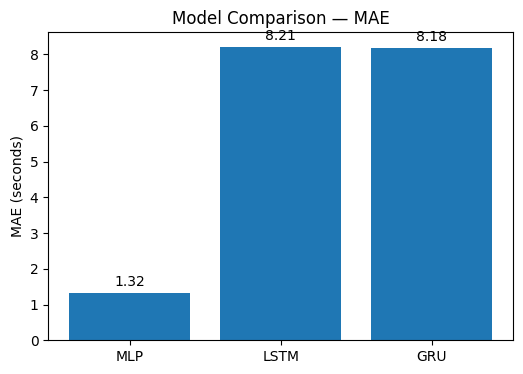

In [ ]:
import matplotlib.pyplot as plt
maes = [1.316993, 8.210352, 8.176895]  # replace with variables if defined
names = ['MLP','LSTM','GRU']

plt.figure(figsize=(6,4))
plt.bar(names, maes)
plt.ylabel('MAE (seconds)')
plt.title('Model Comparison — MAE')
for i,v in enumerate(maes):
    plt.text(i, v + 0.2, f"{v:.2f}", ha='center')
plt.show()


In [ ]:
# Compute per-event MAE for sequence models using last-lap predictions (if you used last-lap many-to-one)
import pandas as pd
from sklearn.metrics import mean_absolute_error

# meta_df maps each sequence index to event in the same order as X_num_test (as you built earlier)
# ensure meta_df_test = meta_df[test_mask] matches X_num_test order
meta_test = meta_df[test_mask].reset_index(drop=True)

# preds: use your saved predictions arrays (y_pred_dl for LSTM/GRU) and y_test2_single
# Example for LSTM:
mae_by_event = []
for ev in meta_test['event'].unique():
    idxs = meta_test[meta_test['event']==ev].index
    if len(idxs)==0:
        continue
    ev_mae = mean_absolute_error(y_test2_single[idxs], y_pred_dl[idxs])
    mae_by_event.append((ev, ev_mae))

pd.DataFrame(mae_by_event, columns=['event','MAE']).sort_values('MAE')


,event,MAE
1,Las Vegas Grand Prix,3.842827
3,Abu Dhabi Grand Prix,6.798669
0,São Paulo Grand Prix,10.850420
2,Qatar Grand Prix,11.913204


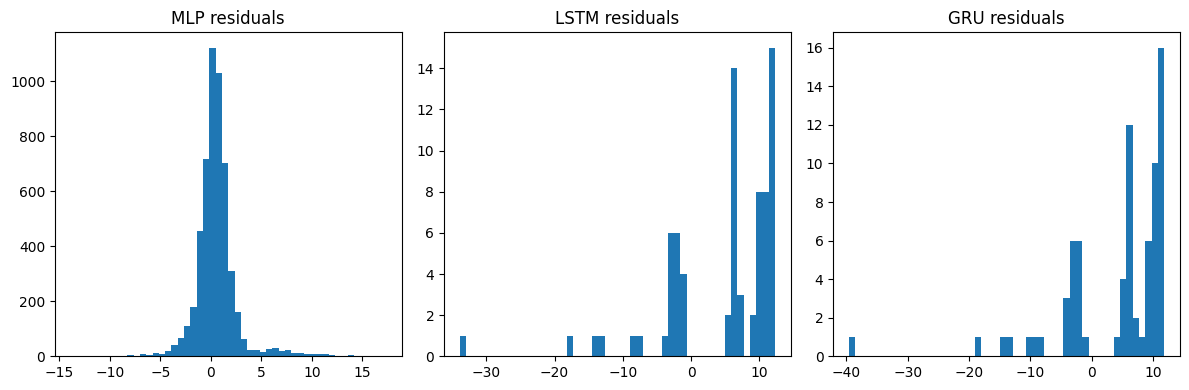

In [ ]:
# Residual histograms
import numpy as np

# Choose arrays: e.g. mlp_preds, y_test_r for MLP; y_pred_dl, y_test2_single for LSTM
res_mlp = pred_mlp - y_test_r
res_lstm = y_pred_dl - y_test2_single
res_gru = pred_gru - y_test2_single

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(res_mlp, bins=50)
plt.title('MLP residuals')
plt.subplot(1,3,2)
plt.hist(res_lstm, bins=50)
plt.title('LSTM residuals')
plt.subplot(1,3,3)
plt.hist(res_gru, bins=50)
plt.title('GRU residuals')
plt.tight_layout()
plt.show()


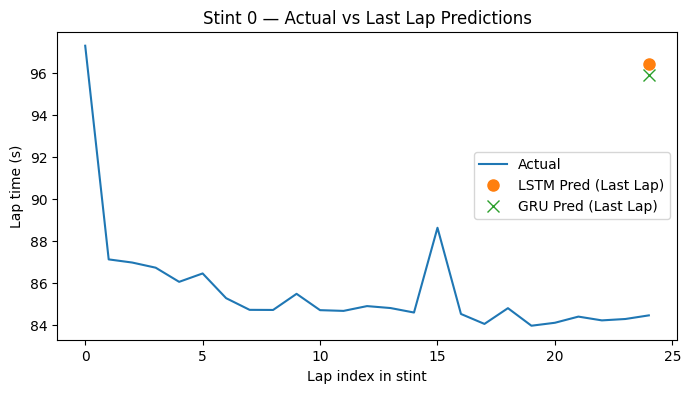

In [ ]:
# pick an example stint index i (non-empty)
i = 0
while i < len(y_test) and y_test[i].sum() == 0:
    i += 1
if i < len(y_test):
    valid = (y_test[i] > 0)
    L = int(valid.sum())
    plt.figure(figsize=(8,4))
    # actual sequence
    plt.plot(range(L), y_test[i,:L], label='Actual')
    # Plot LSTM Many-to-One prediction as a point at the last valid lap
    plt.plot(L-1, y_pred_dl[i], 'o', markersize=8, label='LSTM Pred (Last Lap)')
    # Plot GRU Many-to-One prediction as a point at the last valid lap
    plt.plot(L-1, pred_gru[i], 'x', markersize=8, label='GRU Pred (Last Lap)')
    plt.xlabel('Lap index in stint')
    plt.ylabel('Lap time (s)')
    plt.legend()
    plt.title(f'Stint {i} — Actual vs Last Lap Predictions')
    plt.show()

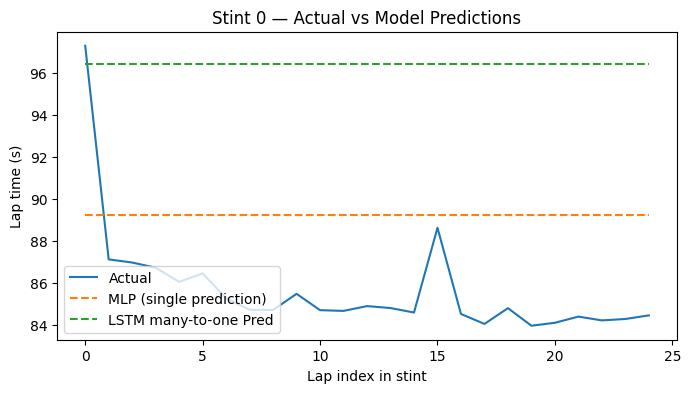

In [ ]:
# -----------------------------
# PLOT ACTUAL VS LSTM VS MLP
# -----------------------------

i = 0
while i < len(y_test) and y_test[i].sum() == 0:
    i += 1

if i < len(y_test):
    valid = (y_test[i] > 0)
    L = int(valid.sum())

    plt.figure(figsize=(8,4))

    # Actual lap sequence
    plt.plot(range(L), y_test[i,:L], label='Actual')

    # LSTM sequence prediction (if you have seq2seq)
    # Only run this if preds_test_lstm exists
    # plt.plot(range(L), preds_test_lstm[i,:L], label="LSTM Sequence Pred")

    # MLP prediction (single value → flat line)
    plt.plot(range(L), [pred_mlp[i]]*L, '--', label='MLP (single prediction)')

    # GRU prediction (also single value)
    plt.plot(range(L), [y_pred_dl[i]]*L, '--', label='LSTM many-to-one Pred')

    plt.xlabel("Lap index in stint")
    plt.ylabel("Lap time (s)")
    plt.title(f"Stint {i} — Actual vs Model Predictions")
    plt.legend()
    plt.show()
